In [137]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import numpy as np
import equinox as eqx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from diffrax import diffeqsolve, ODETerm, SaveAt, Tsit5, PIDController, Dopri5,Kvaerno5


<>:51: SyntaxWarning: invalid escape sequence '\o'
<>:51: SyntaxWarning: invalid escape sequence '\o'
C:\Users\jaosi\AppData\Local\Temp\ipykernel_6288\1957298067.py:51: SyntaxWarning: invalid escape sequence '\o'
  plt.plot(sol_ode.ts/a_0, sol_ode.ys / Mi_val, label= f'$M_i = {Mi_val/M_sol :0f} M_\odot$', color='blue', lw=1.5)


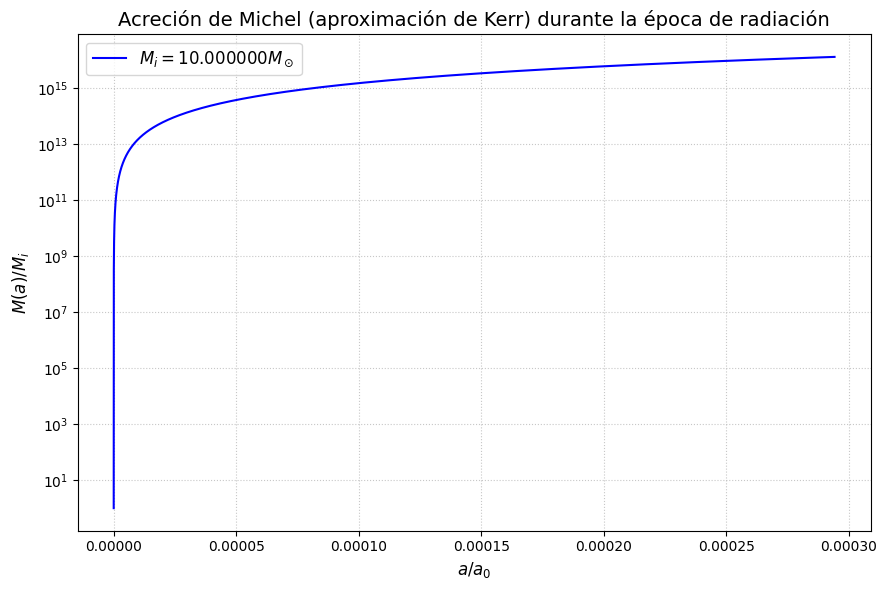

In [148]:
M_sol = 9.136e37 #masas de planck
alpha_evap = 1.0 / (15.0 * 256.0 * jnp.pi)
omega_r=8.4*10**-5
w = 1/3
H_0 = 1.18e-61
G = 1
rho_c= (3*H_0**2)/(8*jnp.pi*G)
rho_0 = omega_r*rho_c
def C4(M, rho_inf_val):
    a_kerr = 0.5 * M
    r_plus = M + jnp.sqrt(M**2.0 - a_kerr**2.0)
    u_c = M / (2.0 * r_plus)
    rho_h = 3.0 * M / (4.0 * jnp.pi * r_plus**3.0)
    return u_c * (rho_h / rho_inf_val)**(1.0 / (1.0 + w))

def correc(a):
    return jnp.sqrt(omega_r)*H_0*a**(-1) #corrección debido al cambio de variable

def crecimiento(a, M, args):
    M_safe = jnp.maximum(M, 1e-20) #función que dice lo máximo a lo que puede caer la evaporación 
    rho_val = rho_0*a**(-4)#densidad de radiación respecto al factor de escala
    C_4 = C4(M_safe, rho_val)
    a_kerr = 0.5 * M_safe
    r_plus = M_safe + jnp.sqrt(M_safe**2.0 - a_kerr**2.0)

    tasa_acrecion = (4.0 * jnp.pi * C_4 * r_plus**2.0 * (rho_val * (1 + w)))/correc(a)
    tasa_evaporacion = - (alpha_evap) / (correc(a) * M_safe**2.0)
    
    return jnp.where(M <= 1e-4, 0.0, tasa_acrecion + tasa_evaporacion) #si la masa es igual o menor que 1, dm/da es igual a 0, si ese no es el caso, se suman las tasas

#Integración con Diffrax
a_0 = 1.0
a_ini = 1e-8
a_fin = 1/3400 
Mi_val =10*M_sol
solver = Kvaerno5()
ode = ODETerm(crecimiento)
stepsize_controller = PIDController(rtol=1e-7, atol=1e-7) 

saveat = SaveAt(ts=jnp.linspace(a_ini, a_fin, 50000))

@eqx.filter_jit
def resolver_ode():
    return diffeqsolve(ode, solver, t0=a_ini, t1=a_fin, dt0=None, 
                       y0=Mi_val, stepsize_controller=stepsize_controller, 
                       saveat=saveat, max_steps=5000000)

sol_ode = resolver_ode()

plt.figure(figsize=(9, 6)) 
plt.plot(sol_ode.ts/a_0, sol_ode.ys / Mi_val, label= f'$M_i = {Mi_val/M_sol :0f} M_\odot$', color='blue', lw=1.5)

plt.xlabel(r'$a/a_0$', fontsize=12)
plt.ylabel(r'$M(a)/M_i$', fontsize=12)
plt.yscale('log')
plt.title(r'Acreción de Michel (aproximación de Kerr) durante la época de radiación', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:41: SyntaxWarning: invalid escape sequence '\o'
<>:36: SyntaxWarning: invalid escape sequence '\c'
<>:41: SyntaxWarning: invalid escape sequence '\o'
C:\Users\jaosi\AppData\Local\Temp\ipykernel_6288\1137014239.py:36: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(sol.ts/a_0, sol.ys / Mi_val, label=f'Spin $\chi={chi}$')
C:\Users\jaosi\AppData\Local\Temp\ipykernel_6288\1137014239.py:41: SyntaxWarning: invalid escape sequence '\o'
  plt.title(f'Efecto del espín en la acreción de Michel($M_i = {Mi_val/M_sol}M_\odot$)', fontsize=14)


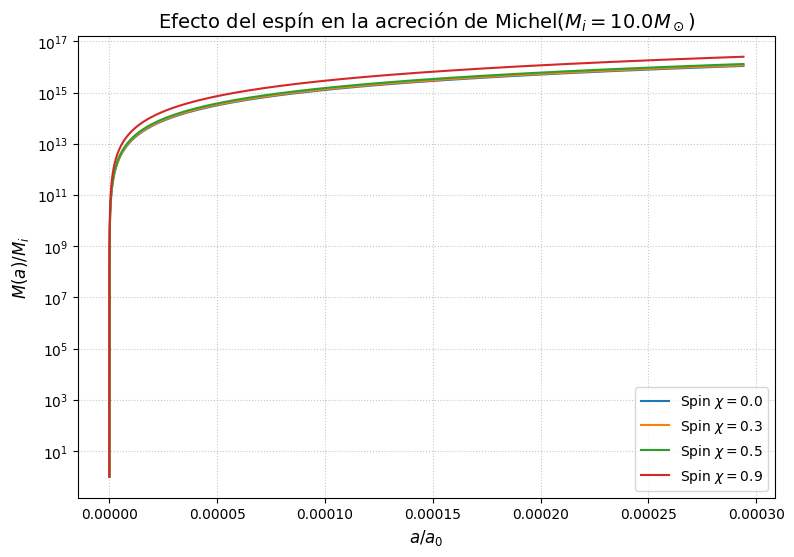

In [149]:

def C4(M, rho_inf_val, chi):
    a_kerr = chi * M
    # Protegemos contra M^2 - a^2 < 0 (agujeros negros extremos)
    a_kerr = jnp.minimum(a_kerr, 0.999 * M) 
    
    r_plus = M + jnp.sqrt(M**2.0 - a_kerr**2.0)
    u_c = M / (2.0 * r_plus)
    rho_h = 3.0 * M / (4.0 * jnp.pi * r_plus**3.0)
    return u_c * (rho_h / rho_inf_val)**(1.0 / (1.0 + w))

def crecimiento(a, M, args):
    chi = args # Aquí recibimos el espín
    M_safe = jnp.maximum(M, 1e-20)
    rho_val = rho_0 * a**(-4.0)
    
    C_4 = C4(M_safe, rho_val, chi)
    
    a_kerr = chi * M_safe
    r_plus = M_safe + jnp.sqrt(M_safe**2.0 - a_kerr**2.0)

    tasa_acrecion = (4.0 * jnp.pi * C_4 * r_plus**2.0 * (rho_val * (1.0 + w))) / correc(a)
    tasa_evaporacion = - (alpha_evap) / (correc(a) * M_safe**2.0)
    
    return jnp.where(M <= 1e-4, 0.0, tasa_acrecion + tasa_evaporacion)


spins = [0.0, 0.3,0.5, 0.9] # Valores de chi a probar
plt.figure(figsize=(9, 6))

for chi in spins:
    ode = ODETerm(crecimiento)
    sol = diffeqsolve(ode, solver, t0=a_ini, t1=a_fin, dt0=1e-12, 
                      y0=Mi_val, stepsize_controller=stepsize_controller, 
                      saveat=saveat, max_steps=5000000, args=chi)
    
    plt.plot(sol.ts/a_0, sol.ys / Mi_val, label=f'Spin $\chi={chi}$')

plt.xlabel(r'$a/a_0$', fontsize=12)
plt.ylabel(r'$M(a)/M_i$', fontsize=12)
plt.yscale('log')
plt.title(f'Efecto del espín en la acreción de Michel($M_i = {Mi_val/M_sol}M_\odot$)', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()

C:\tools\Manim\Lib\site-packages\scipy\integrate\_ivp\radau.py:171: RuntimeWarning: divide by zero encountered in scalar divide
  multiplier = h_abs / h_abs_old * (error_norm_old / error_norm) ** 0.25


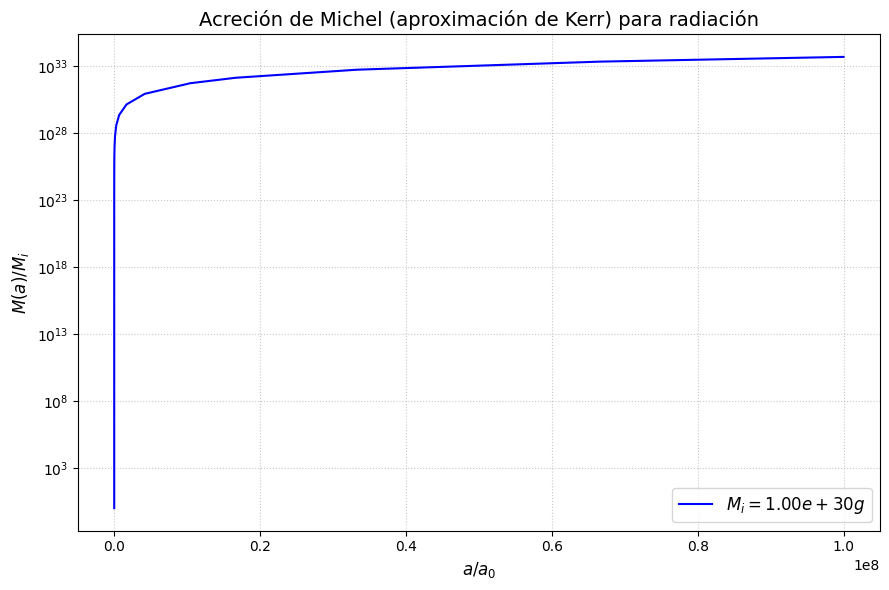

In [ ]:
M_sol = 1.988e33 #masas solares en g
hbar = 1.05e-27 #g cm^2 s^-1
omega_r = 8.4e-5
w = 1.0 / 3.0
c = 3e10 #cm s^-1
H_0 = 2.189e-18  # s^-1
G = 6.674e-8     # cm^3 g^-1 s^-2
alpha_evap = (hbar*c**4) / (15.0 * 256.0 * np.pi * G**2)
rho_c= (3*H_0**2)/(8*np.pi*G)
rho_0 = omega_r*rho_c
def C4(M, rho_inf_val):
    a_kerr = 0.5 
    r_plus = (G*M/c**2)*(1 + np.sqrt(1.0 - a_kerr**2.0))
    u_c =  c/np.sqrt(3)#M / (2.0 * r_plus)
    rho_h = 3.0 * M / (4.0 * np.pi * r_plus**3.0)
    return u_c * (rho_h / rho_inf_val)**(1.0 / (1.0 + w))

def correc(a):
    return np.sqrt(omega_r)*H_0*a**(-1.0) #corrección debido al cambio de variable

def crecimiento(a, M_arr):
    M = M_arr[0]
    rho_val = rho_0*a**(-4) / c**2 #densidad de radiación respecto al factor de escala
    C_4 = C4(M, rho_val)
    a_kerr = 0.5
    r_plus = (G*M/c**2)*(1 + np.sqrt(1.0- a_kerr**2.0))

    tasa_acrecion = (4.0 * np.pi * C_4 * r_plus**2.0 * (rho_val * (1 + w)))/correc(a)
    tasa_evaporacion = - (alpha_evap) / (correc(a) * M**2.0)
    dM_da = tasa_acrecion + tasa_evaporacion
    return [dM_da] #si la masa es igual o menor que 1, dm/da es igual a 0, si ese no es el caso, se suman las tasas

def detener_evaporacion(a, M_arr):
    return M_arr[0] - 1.0
detener_evaporacion.terminal = True
detener_evaporacion.direction = -1


#Integración con Diffrax
a_0 = 1.0
a_ini = 1.0
a_fin = 1e8
Mi_val = 1e30

sol = solve_ivp(
    fun = crecimiento,
    t_span = (a_ini,a_fin),
    y0 = [Mi_val],
    method = 'Radau',
    events = detener_evaporacion,
    rtol = 1e-10,
    atol = 1e-20
)

plt.figure(figsize=(9, 6)) 
plt.semilogy(sol.t/a_0, sol.y[0] / Mi_val, label= f'$M_i = {Mi_val:.2e} g$', color='blue', lw=1.5)
plt.xlabel(r'$a/a_0$', fontsize=12)
plt.ylabel(r'$M(a)/M_i$', fontsize=12)
plt.title(r'Acreción de Michel (aproximación de Kerr) para radiación', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

<>:50: SyntaxWarning: invalid escape sequence '\c'
<>:50: SyntaxWarning: invalid escape sequence '\c'
C:\Users\jaosi\AppData\Local\Temp\ipykernel_6288\4173922020.py:50: SyntaxWarning: invalid escape sequence '\c'
  plt.semilogy(sol.t/a_0, sol.y[0] / Mi_val, label=f'Spin $\chi={chi}$')


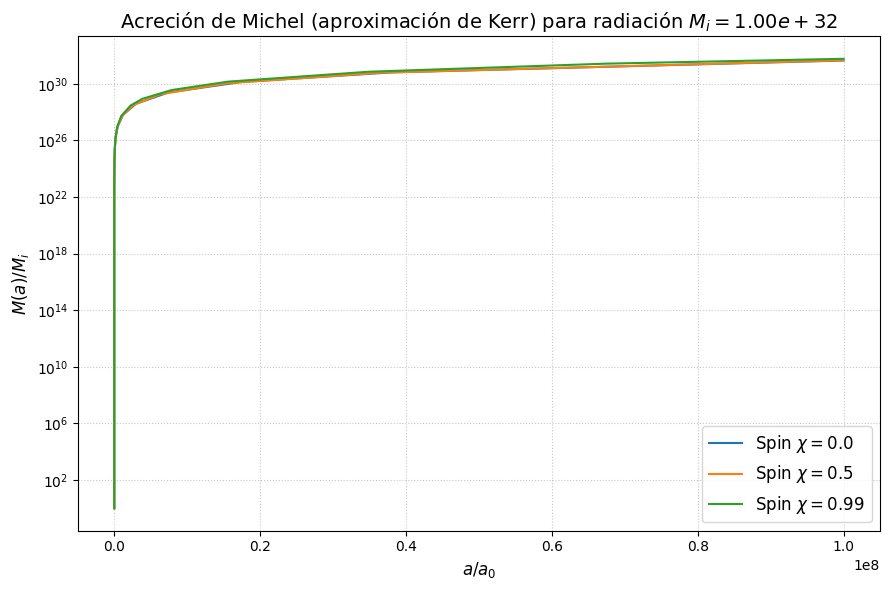

In [ ]:
def C4(M, rho_inf_val, chi):
    a_kerr = chi 
    # Protegemos contra M^2 - a^2 < 0 (agujeros negros extremos)
    a_kerr = jnp.minimum(a_kerr, 0.999 )
    r_plus = (G*M/c**2)*(1 + np.sqrt(1.0 - a_kerr**2.0))
    u_c =  c/np.sqrt(3)#M / (2.0 * r_plus)
    rho_h = 3.0 * M / (4.0 * np.pi * r_plus**3.0)
    return u_c * (rho_h / rho_inf_val)**(1.0 / (1.0 + w))

def correc(a):
    return np.sqrt(omega_r)*H_0*a**(-1.0) #corrección debido al cambio de variable

def crecimiento(a, M_arr):
    M = M_arr[0]
    rho_val = rho_0*a**(-4) / c**2 #densidad de radiación respecto al factor de escala
    C_4 = C4(M, rho_val, chi)
    a_kerr = chi
    r_plus = (G*M/c**2)*(1 + np.sqrt(1.0- a_kerr**2.0))

    tasa_acrecion = (4.0 * np.pi * C_4 * r_plus**2.0 * (rho_val * (1 + w)))/correc(a)
    tasa_evaporacion = - (alpha_evap) / (correc(a) * M**2.0)
    dM_da = tasa_acrecion + tasa_evaporacion
    return [dM_da] #si la masa es igual o menor que 1, dm/da es igual a 0, si ese no es el caso, se suman las tasas

def detener_evaporacion(a, M_arr):
    return M_arr[0] - 1.0
detener_evaporacion.terminal = True
detener_evaporacion.direction = -1


#Integración con Diffrax
a_0 = 1.0
a_ini = 1.0
a_fin = 1e8
Mi_val = 10e31

spins = [0.0,0.5, 0.99] # Valores de chi a probar
plt.figure(figsize=(9, 6))

for chi in spins:
    sol = solve_ivp(
    fun = crecimiento,
    t_span = (a_ini,a_fin),
    y0 = [Mi_val],
    method = 'Radau',
    events = detener_evaporacion,
    rtol = 1e-10,
    atol = 1e-20
)
    plt.semilogy(sol.t/a_0, sol.y[0] / Mi_val, label=f'Spin $\chi={chi}$')

plt.xlabel(r'$a/a_0$', fontsize=12)
plt.ylabel(r'$M(a)/M_i$', fontsize=12)
plt.title(f'Acreción de Michel (aproximación de Kerr) para radiación $M_i = {Mi_val:.2e}$', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show() 